In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from sklearn.inspection import permutation_importance

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("/kaggle/input/notebooks/jigishadas/ssi-creation/dataset_with_ssi.csv")

In [5]:
X = df.drop(
    columns=[
        "language",
        "repository",
        "function",
        "SSI"
    ]
)

y = df["SSI"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 32)
(400, 32)


In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [8]:
y_pred = rf.predict(X_test)

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.215512210856854
RMSE: 0.4731165442281111
R²  : 0.9730194780754546


In [10]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(scores)
print("Mean:", scores.mean())

[0.98592689 0.95463588 0.91573019 0.9708804  0.97015247]
Mean: 0.959465164878582


In [11]:
# PCA analysis for SSI explainability

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Number of PCA components:", pca.n_components_)

Number of PCA components: 32


In [12]:
# PC1 loadings = contribution of each feature to SSI

pc1_loadings = pd.DataFrame({
    "Feature": X.columns,
    "PC1 Loading": pca.components_[0],
    "Absolute PC1 Loading": np.abs(pca.components_[0])
}).sort_values(
    "Absolute PC1 Loading",
    ascending=False
)

display(pc1_loadings)

,Feature,PC1 Loading,Absolute PC1 Loading
17,ast_nodes,0.277020,0.277020
18,leaf_nodes,0.275924,0.275924
19,internal_nodes,0.275394,0.275394
13,identifier_count,0.274766,0.274766
14,block_count,0.255293,0.255293
30,cyclomatic_estimate,0.251410,0.251410
4,if_count,0.239198,0.239198
9,call_count,0.231493,0.231493
10,argument_count,0.228998,0.228998
2,variable_count,0.227543,0.227543


In [13]:
# Permutation Feature Importance

perm_result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

pfi_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values(
    "Importance Mean",
    ascending=False
)

display(pfi_df)

,Feature,Importance Mean,Importance Std
17,ast_nodes,5.529486e-01,0.019052
19,internal_nodes,1.124758e-01,0.004257
18,leaf_nodes,4.364304e-02,0.001897
14,block_count,1.327624e-02,0.000605
30,cyclomatic_estimate,9.214242e-03,0.000458
13,identifier_count,6.375803e-03,0.000247
2,variable_count,5.334255e-03,0.000316
4,if_count,4.376714e-03,0.000286
23,branch_density,4.123914e-03,0.000436
11,assignment_count,1.495927e-03,0.000144


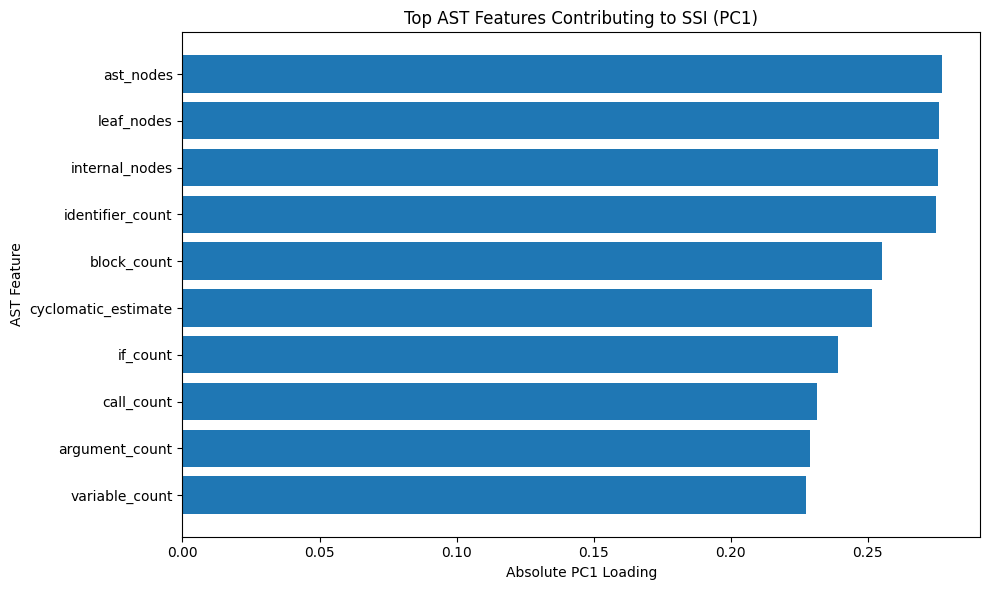

In [14]:
top_n = 10

top_pc1 = pc1_loadings.head(top_n).sort_values(
    "Absolute PC1 Loading"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_pc1["Feature"],
    top_pc1["Absolute PC1 Loading"]
)

plt.xlabel("Absolute PC1 Loading")
plt.ylabel("AST Feature")
plt.title("Top AST Features Contributing to SSI (PC1)")

plt.tight_layout()
plt.show()

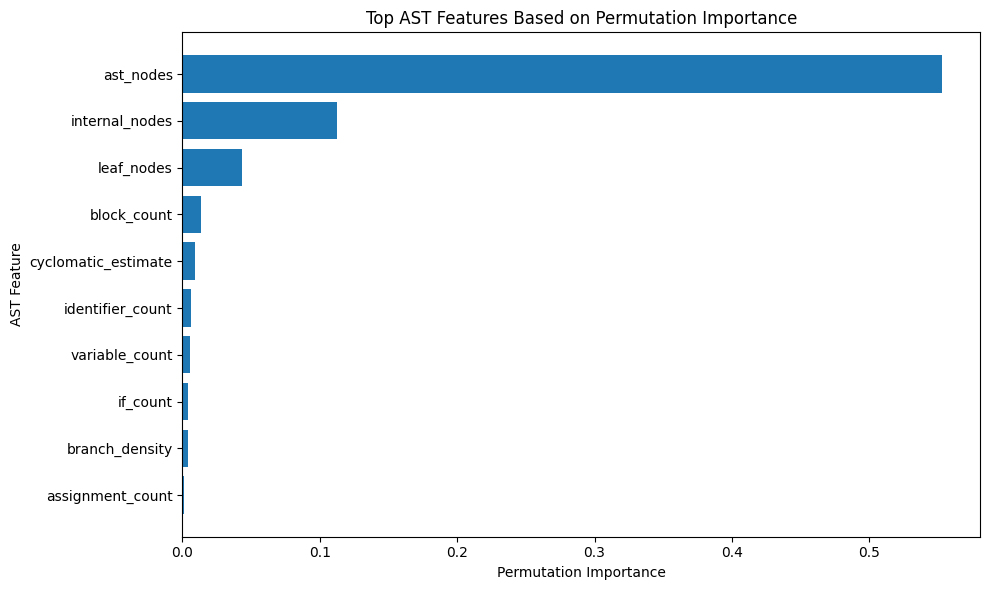

In [15]:
top_pfi = pfi_df.head(10).sort_values(
    "Importance Mean"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_pfi["Feature"],
    top_pfi["Importance Mean"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("AST Feature")
plt.title("Top AST Features Based on Permutation Importance")

plt.tight_layout()
plt.show()

In [16]:
# Compare PCA loading importance and permutation importance

comparison_df = pd.merge(
    pc1_loadings[["Feature", "Absolute PC1 Loading"]],
    pfi_df[["Feature", "Importance Mean"]],
    on="Feature",
    how="inner"
)

comparison_df = comparison_df.sort_values(
    "Absolute PC1 Loading",
    ascending=False
)

display(comparison_df)

,Feature,Absolute PC1 Loading,Importance Mean
0,ast_nodes,0.277020,5.529486e-01
1,leaf_nodes,0.275924,4.364304e-02
2,internal_nodes,0.275394,1.124758e-01
3,identifier_count,0.274766,6.375803e-03
4,block_count,0.255293,1.327624e-02
5,cyclomatic_estimate,0.251410,9.214242e-03
6,if_count,0.239198,4.376714e-03
7,call_count,0.231493,2.308161e-04
8,argument_count,0.228998,2.570971e-04
9,variable_count,0.227543,5.334255e-03


In [17]:
comparison_df["PC1 Rank"] = (
    comparison_df["Absolute PC1 Loading"]
    .rank(ascending=False, method="min")
)

comparison_df["PFI Rank"] = (
    comparison_df["Importance Mean"]
    .rank(ascending=False, method="min")
)

comparison_df = comparison_df.sort_values("PC1 Rank")

display(comparison_df)

,Feature,Absolute PC1 Loading,Importance Mean,PC1 Rank,PFI Rank
0,ast_nodes,0.277020,5.529486e-01,1.0,1.0
1,leaf_nodes,0.275924,4.364304e-02,2.0,3.0
2,internal_nodes,0.275394,1.124758e-01,3.0,2.0
3,identifier_count,0.274766,6.375803e-03,4.0,6.0
4,block_count,0.255293,1.327624e-02,5.0,4.0
5,cyclomatic_estimate,0.251410,9.214242e-03,6.0,5.0
6,if_count,0.239198,4.376714e-03,7.0,8.0
7,call_count,0.231493,2.308161e-04,8.0,19.0
8,argument_count,0.228998,2.570971e-04,9.0,18.0
9,variable_count,0.227543,5.334255e-03,10.0,7.0
